##K-means clustering
Computation

/tmp/ipython-input-4226525652.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=30, cmap='viridis')


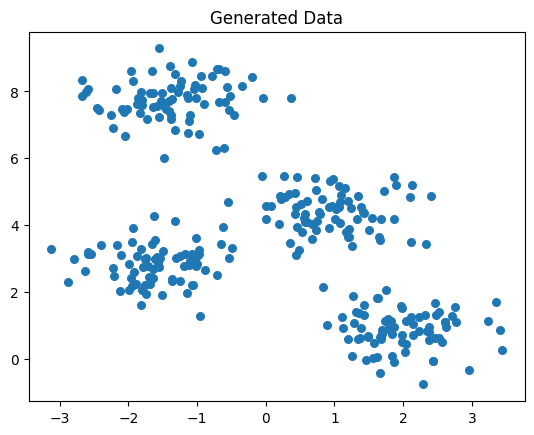

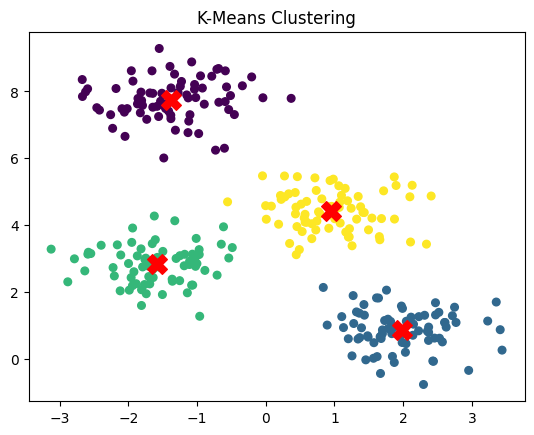

Cluster labels: [1 0 3 0 1 1 2 3 0 0 2 0 3 0 1 3 3 1 2 2 1 1 3 2 2 3 1 3 2 3 0 0 3 0 0 0 0
 0 2 1 3 2 3 3 2 2 0 2 0 1 2 1 0 1 1 2 0 2 0 1 0 3 0 2 2 2 0 1 0 2 3 2 0 2
 2 0 2 3 1 0 1 3 1 1 0 3 1 3 0 0 3 1 0 2 2 3 1 1 3 2 0 1 0 1 3 1 1 3 0 3 2
 2 1 0 1 3 0 1 1 3 2 1 2 1 1 1 1 2 1 2 0 2 2 1 0 2 2 0 3 0 0 2 3 2 3 2 0 3
 0 0 0 3 0 3 1 2 0 2 1 3 0 3 3 1 3 2 2 3 1 3 3 0 1 3 2 0 1 1 3 2 1 3 2 2 3
 3 3 3 1 0 3 2 3 3 2 2 2 3 2 0 3 2 1 2 3 0 2 0 3 0 3 2 3 3 0 2 2 1 1 3 0 1
 1 2 1 2 3 0 0 3 3 0 3 1 2 3 1 2 0 2 1 3 1 0 0 0 0 2 2 0 3 2 1 3 2 2 2 1 1
 0 3 3 2 1 0 2 3 0 3 1 1 2 2 3 1 1 1 3 0 0 1 1 3 1 1 1 0 2 0 3 1 1 0 0 0 1
 1 3 0 2]


In [ ]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Create a sample dataset using make_blobs
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Plotting the data points
plt.scatter(X[:, 0], X[:, 1], s=30, cmap='viridis')
plt.title("Generated Data")
plt.show()

# Applying K-Means clustering
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)

# Getting the cluster centers and labels
centers = kmeans.cluster_centers_
labels = kmeans.labels_

# Plotting the clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X')
plt.title("K-Means Clustering")
plt.show()

# You can also get the labels of each data point like this
print("Cluster labels:", labels)

How k-means clustering works

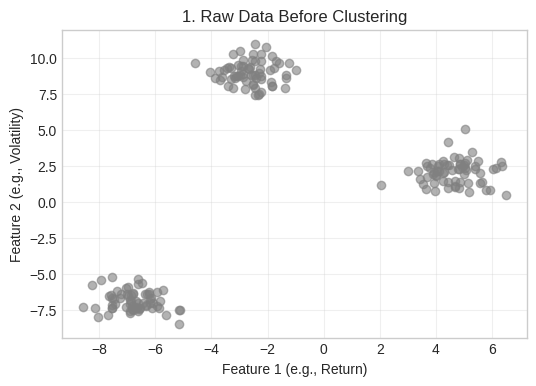

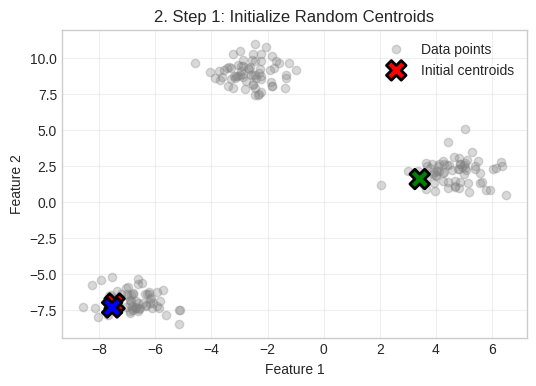

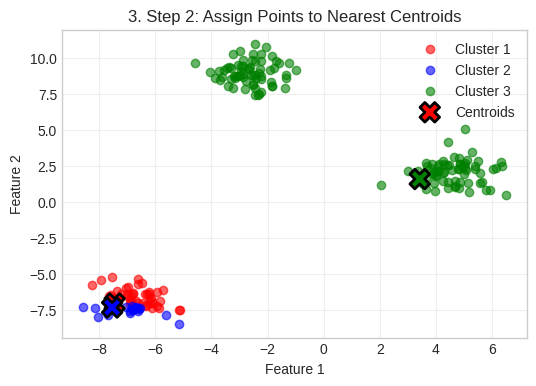

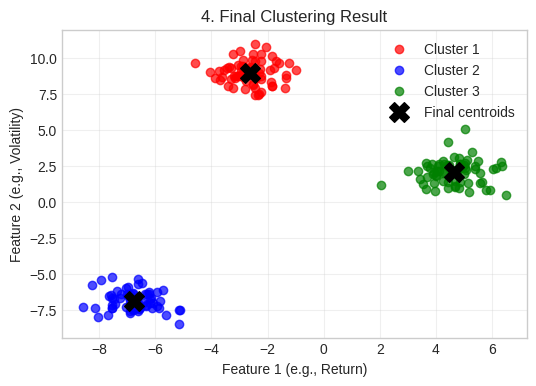

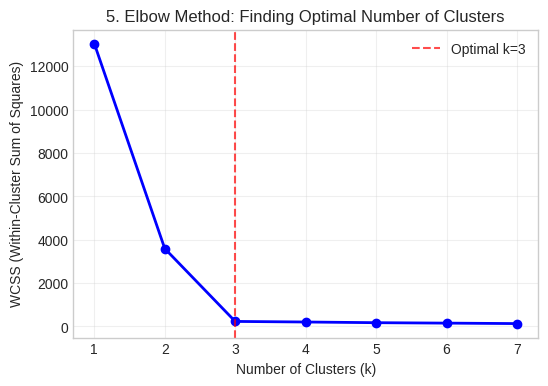

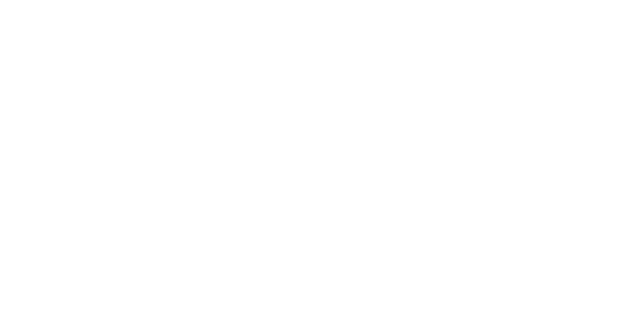

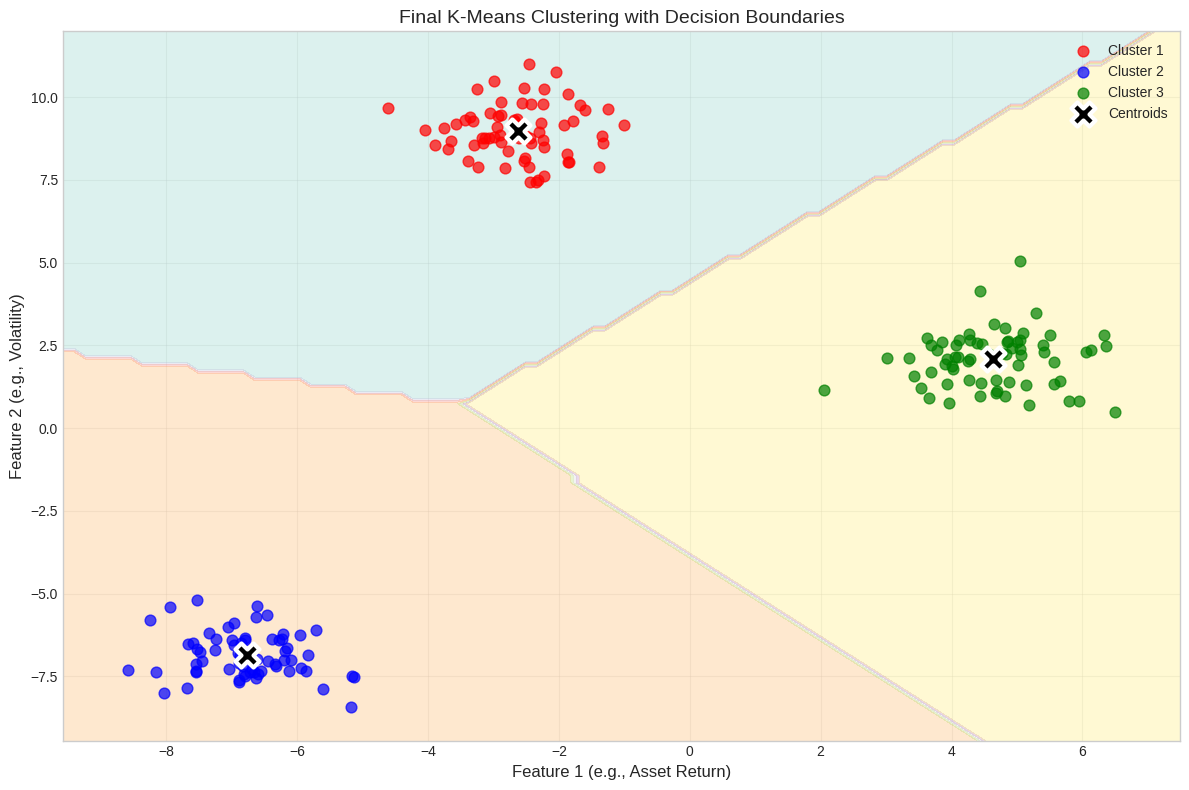

<Figure size 640x480 with 0 Axes>

In [ ]:
# Create sample data (like financial instruments with two features)
np.random.seed(42)
X, _ = make_blobs(n_samples=200, centers=3, cluster_std=0.8, random_state=42)

# VISUAL 1: Raw Data Before Clustering
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.6)
plt.title('1. Raw Data Before Clustering')
plt.xlabel('Feature 1 (e.g., Return)')
plt.ylabel('Feature 2 (e.g., Volatility)')
plt.grid(True, alpha=0.3)
plt.show()

# VISUAL 2: K-means Steps (Simplified)
# Step 1: Initialize random centroids
np.random.seed(42)
initial_centroids = X[np.random.choice(X.shape[0], 3, replace=False)]

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.3, label='Data points')
plt.scatter(initial_centroids[:, 0], initial_centroids[:, 1],
           marker='X', s=200, c=['red', 'blue', 'green'],
           edgecolor='black', linewidth=2, label='Initial centroids')
plt.title('2. Step 1: Initialize Random Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Step 2: Assign points to nearest centroids
kmeans_temp = KMeans(n_clusters=3, init=initial_centroids, n_init=1, max_iter=1)
labels = kmeans_temp.fit_predict(X)

plt.figure(figsize=(6, 4))
colors = ['red', 'blue', 'green']
for i in range(3):
    cluster_points = X[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
               c=colors[i], alpha=0.6, label=f'Cluster {i+1}')
plt.scatter(initial_centroids[:, 0], initial_centroids[:, 1],
           marker='X', s=200, c=['red', 'blue', 'green'],
           edgecolor='black', linewidth=2, label='Centroids')
plt.title('3. Step 2: Assign Points to Nearest Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# VISUAL 3: Final Clustering Result
# Apply k-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
final_labels = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(6, 4))
for i in range(3):
    cluster_points = X[final_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
               c=colors[i], alpha=0.7, label=f'Cluster {i+1}')
plt.scatter(centroids[:, 0], centroids[:, 1],
           marker='X', s=200, c='black', label='Final centroids')
plt.title('4. Final Clustering Result')
plt.xlabel('Feature 1 (e.g., Return)')
plt.ylabel('Feature 2 (e.g., Volatility)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# VISUAL 4: Elbow Method for Choosing K
# Test different numbers of clusters
k_values = range(1, 8)
wcss = []  # Within-cluster sum of squares

for k in k_values:
    kmeans_test = KMeans(n_clusters=k, random_state=42)
    kmeans_test.fit(X)
    wcss.append(kmeans_test.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(k_values, wcss, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('5. Elbow Method: Finding Optimal Number of Clusters')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)

# Mark the "elbow" point
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Optimal k=3')
plt.legend()
plt.show()

# VISUAL 5: Simple Flowchart
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')

# Create a simple text-based flowchart
flowchart_text = """
K-MEANS CLUSTERING ALGORITHM

1. RANDOMLY INITIALIZE K CENTROIDS
   ↓
2. ASSIGN EACH POINT TO NEAREST CENTROID
   ↓
3. UPDATE CENTROIDS (Calculate mean of points in each cluster)
   ↓
4. REPEAT STEPS 2-3 UNTIL CENTROIDS STOP MOVING
   ↓
5. FINAL CLUSTERS OBTAINED
"""

# VISUAL 6: Final Clustering Result with Decision Boundaries
def plot_final_clustering_with_boundaries(X, k=3):
    """Plot final clustering result with Voronoi-like decision boundaries"""
    # Fit k-means
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    centroids = kmeans.cluster_centers_

    # Create mesh grid for decision boundaries
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Predict clusters for mesh points
    Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(12, 8))

    # Plot decision boundaries
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set3)

    # Plot data points
    colors = ['red', 'blue', 'green']
    for i in range(k):
        cluster_points = X[labels == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                   c=colors[i], alpha=0.7, s=60, label=f'Cluster {i+1}')

    # Plot centroids
    plt.scatter(centroids[:, 0], centroids[:, 1],
               c='black', marker='X', s=300, linewidth=3,
               label='Centroids', edgecolor='white')

    plt.xlabel('Feature 1 (e.g., Asset Return)', fontsize=12)
    plt.ylabel('Feature 2 (e.g., Volatility)', fontsize=12)
    plt.title('Final K-Means Clustering with Decision Boundaries', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_final_clustering_with_boundaries(X)

ax.text(0.1, 0.9, flowchart_text, fontsize=12, fontfamily='monospace',
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue"))
ax.set_title('6. K-means Algorithm Flowchart', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

##Principal Component Analysis (PCA)

=== PRINCIPAL COMPONENT ANALYSIS (PCA) DEMONSTRATION ===

1. Loading financial data...


[*********************100%***********************]  20 of 20 completed


Online download failed, creating synthetic data...
Returns data shape: (730, 20)

2. Preprocessing data...
Standardized returns shape: (730, 20)

3. Performing PCA...
Number of components: 20
Explained variance ratio: [0.06499417 0.06199733 0.05917959 0.05773233 0.05706213 0.0558989
 0.05516753 0.05338794 0.05143241 0.05076137 0.04991061 0.04847736
 0.04665496 0.04573174 0.04410852 0.04263176 0.04177124 0.03980985
 0.03800307 0.03528717]

4. Creating visualizations...


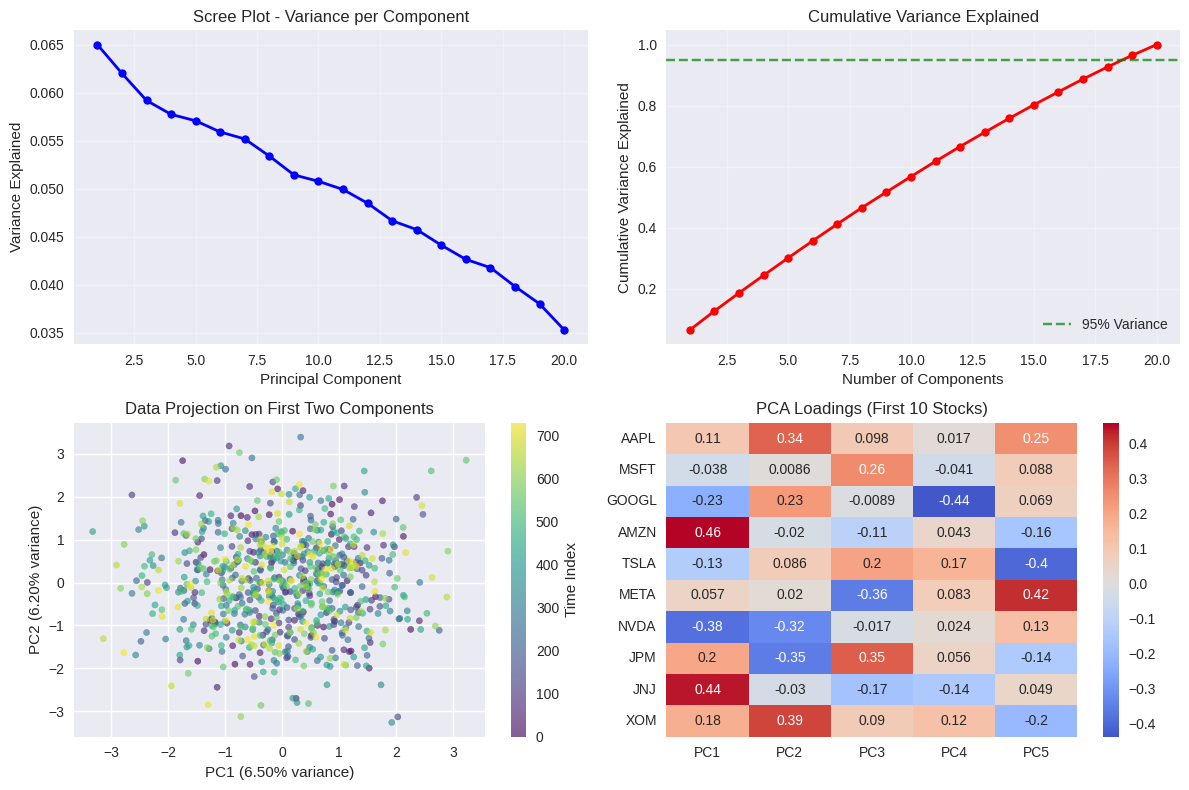


5. Detailed analysis...
Components needed for 95% variance: 19
Optimal components shape: (730, 19)
Variance explained with 19 components: 96.47%

6. Component interpretation...
Top 10 stocks contributing to PC1 (Market Factor):
Stock   Loading  Abs_Loading
 AMZN  0.460065     0.460065
  JNJ  0.441723     0.441723
 NVDA -0.382261     0.382261
 NFLX  0.289185     0.289185
   KO -0.265065     0.265065
GOOGL -0.233278     0.233278
  WMT -0.220639     0.220639
  JPM  0.199261     0.199261
  PEP  0.179391     0.179391
  XOM  0.178487     0.178487

7. Creating additional visualizations...


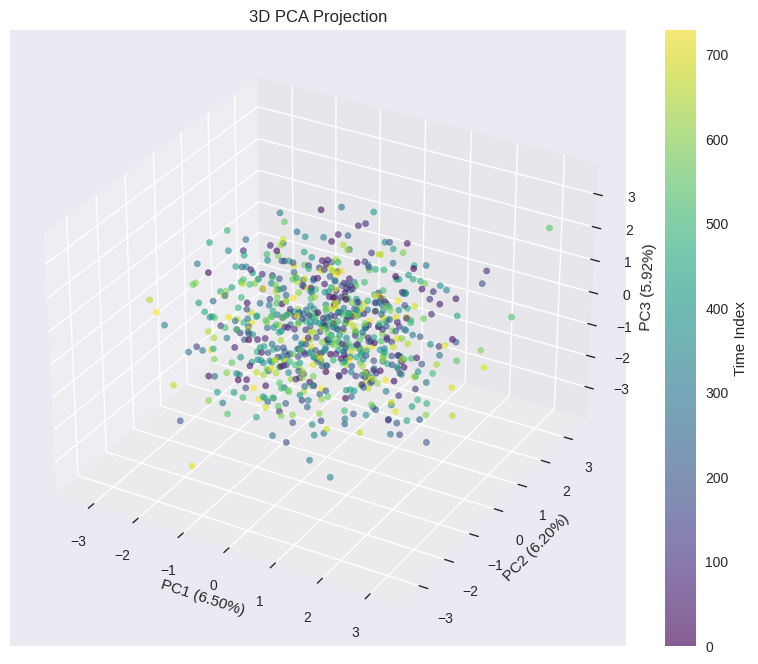

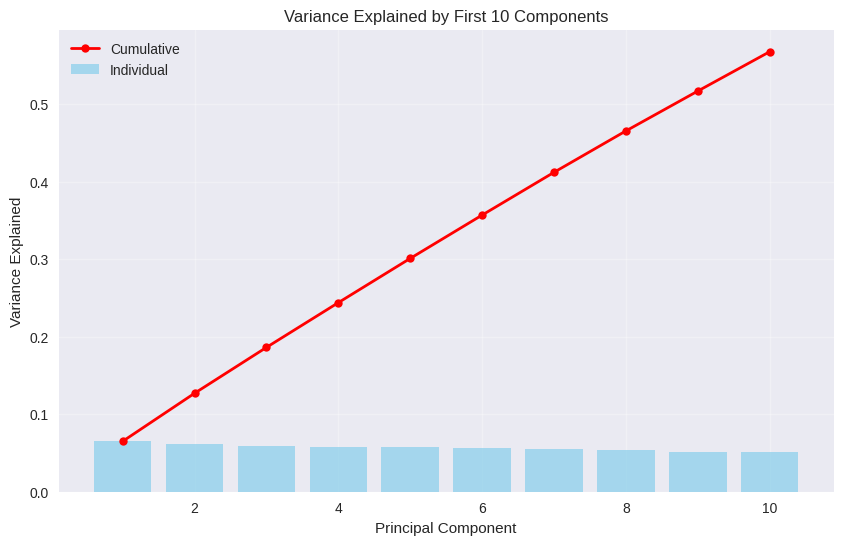


8. Summary statistics:
Original data dimensions: (730, 20)
Data reduction: 20 → 19 components
Dimensionality reduction: 5.0%

9. Saving results...
Loadings saved to 'pca_loadings.csv'
Transformed data saved to 'pca_transformed_data.csv'

=== PCA ANALYSIS COMPLETE ===
Generated files:
- pca_analysis.png (main analysis figure)
- pca_3d_projection.png (3D visualization)
- pca_variance_explained.png (variance chart)
- pca_loadings.csv (component loadings)
- pca_transformed_data.csv (transformed data)


In [ ]:
# Principal Component Analysis (PCA) - Financial Data Example
# adj code: Complete implementation with visualization and figure saving

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("=== PRINCIPAL COMPONENT ANALYSIS (PCA) DEMONSTRATION ===\n")

# 1. Load Sample Financial Data (Stock Returns)
print("1. Loading financial data...")

# Define stock tickers for portfolio
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'JPM', 'JNJ', 'XOM',
           'BAC', 'WMT', 'PG', 'DIS', 'NFLX', 'AMD', 'INTC', 'CSCO', 'PEP', 'KO']

# Download historical data (last 2 years)
try:
    data = yf.download(tickers, start='2022-01-01', end='2024-01-01')['Adj Close']
    print(f"Downloaded data for {len(tickers)} stocks")
except:
    print("Online download failed, creating synthetic data...")
    # Create synthetic returns data if download fails
    np.random.seed(42)
    dates = pd.date_range('2022-01-01', '2024-01-01', freq='D')
    data = pd.DataFrame(np.random.randn(len(dates), len(tickers)) * 0.02 + 0.001,
                       index=dates, columns=tickers)
    # Convert to price-like data
    data = (1 + data).cumprod() * 100

# Calculate daily returns
returns = data.pct_change().dropna()
print(f"Returns data shape: {returns.shape}")

# 2. Data Preprocessing
print("\n2. Preprocessing data...")

# Handle any missing values
returns = returns.fillna(returns.mean())

# Standardize the data (critical for PCA)
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

print(f"Standardized returns shape: {returns_scaled.shape}")

# 3. Perform PCA
print("\n3. Performing PCA...")

# Fit PCA without specifying number of components first
pca = PCA()
pca.fit(returns_scaled)

# Get the principal components
components = pca.transform(returns_scaled)

print(f"Number of components: {pca.n_components_}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

# 4. Create Visualization Figures
print("\n4. Creating visualizations...")

# Figure 1: Scree Plot
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
# Scree plot - variance explained by each component
components_range = range(1, len(pca.explained_variance_ratio_) + 1)
plt.plot(components_range, pca.explained_variance_ratio_, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot - Variance per Component')
plt.grid(True, alpha=0.3)

# Cumulative variance
plt.subplot(2, 2, 2)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(components_range, cumulative_variance, 'ro-', linewidth=2, markersize=6)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance Explained')
plt.axhline(y=0.95, color='g', linestyle='--', alpha=0.7, label='95% Variance')
plt.legend()
plt.grid(True, alpha=0.3)

# Figure 2: First two components visualization
plt.subplot(2, 2, 3)
# Plot first two principal components
plt.scatter(components[:, 0], components[:, 1], alpha=0.6, c=range(len(components)),
           cmap='viridis', s=20)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Data Projection on First Two Components')
plt.colorbar(label='Time Index')

# Figure 3: Component loadings (heatmap)
plt.subplot(2, 2, 4)
# Show loadings for first 5 components on first 10 stocks
loadings = pca.components_.T
sns.heatmap(loadings[:10, :5], annot=True, cmap='coolwarm', center=0,
           xticklabels=[f'PC{i+1}' for i in range(5)],
           yticklabels=returns.columns[:10])
plt.title('PCA Loadings (First 10 Stocks)')

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Detailed Analysis
print("\n5. Detailed analysis...")

# Find number of components for 95% variance
n_components_95 = np.where(cumulative_variance >= 0.95)[0][0] + 1
print(f"Components needed for 95% variance: {n_components_95}")

# Fit PCA with optimal number of components
pca_optimal = PCA(n_components=n_components_95)
components_optimal = pca_optimal.fit_transform(returns_scaled)

print(f"Optimal components shape: {components_optimal.shape}")
print(f"Variance explained with {n_components_95} components: {cumulative_variance[n_components_95-1]:.2%}")

# 6. Component Interpretation
print("\n6. Component interpretation...")

# Analyze first component loadings (often represents "market" factor)
first_component_loadings = pd.DataFrame({
    'Stock': returns.columns,
    'Loading': pca.components_[0],
    'Abs_Loading': np.abs(pca.components_[0])
}).sort_values('Abs_Loading', ascending=False)

print("Top 10 stocks contributing to PC1 (Market Factor):")
print(first_component_loadings.head(10).to_string(index=False))

# 7. Create additional specialized plots
print("\n7. Creating additional visualizations...")

# Figure 2: 3D visualization if we have enough components
if pca.n_components_ >= 3:
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(components[:, 0], components[:, 1], components[:, 2],
                        c=range(len(components)), cmap='viridis', alpha=0.6)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%})')
    ax.set_title('3D PCA Projection')
    plt.colorbar(scatter, ax=ax, label='Time Index')
    plt.savefig('pca_3d_projection.png', dpi=300, bbox_inches='tight')
    plt.show()

# Figure 3: Variance explained bar chart
plt.figure(figsize=(10, 6))
plt.bar(components_range[:10], pca.explained_variance_ratio_[:10], alpha=0.7, color='skyblue')
plt.plot(components_range[:10], cumulative_variance[:10], 'ro-', linewidth=2, markersize=6)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained by First 10 Components')
plt.legend(['Cumulative', 'Individual'])
plt.grid(True, alpha=0.3)
plt.savefig('pca_variance_explained.png', dpi=300, bbox_inches='tight')
plt.show()

# 8. Summary Statistics
print("\n8. Summary statistics:")
print(f"Original data dimensions: {returns_scaled.shape}")
print(f"Data reduction: {returns_scaled.shape[1]} → {n_components_95} components")
reduction_ratio = (1 - n_components_95/returns_scaled.shape[1]) * 100
print(f"Dimensionality reduction: {reduction_ratio:.1f}%")

# 9. Save results to files
print("\n9. Saving results...")

# Save loadings to CSV
loadings_df = pd.DataFrame(pca.components_.T,
                          index=returns.columns,
                          columns=[f'PC{i+1}' for i in range(pca.n_components_)])
loadings_df.to_csv('pca_loadings.csv')
print("Loadings saved to 'pca_loadings.csv'")

# Save transformed data
components_df = pd.DataFrame(components_optimal,
                            index=returns.index,
                            columns=[f'PC{i+1}' for i in range(n_components_95)])
components_df.to_csv('pca_transformed_data.csv')
print("Transformed data saved to 'pca_transformed_data.csv'")

print("\n=== PCA ANALYSIS COMPLETE ===")
print("Generated files:")
print("- pca_analysis.png (main analysis figure)")
print("- pca_3d_projection.png (3D visualization)")
print("- pca_variance_explained.png (variance chart)")
print("- pca_loadings.csv (component loadings)")
print("- pca_transformed_data.csv (transformed data)")

##Regression trees model

Test MSE: 0.010469, R2: 0.1948


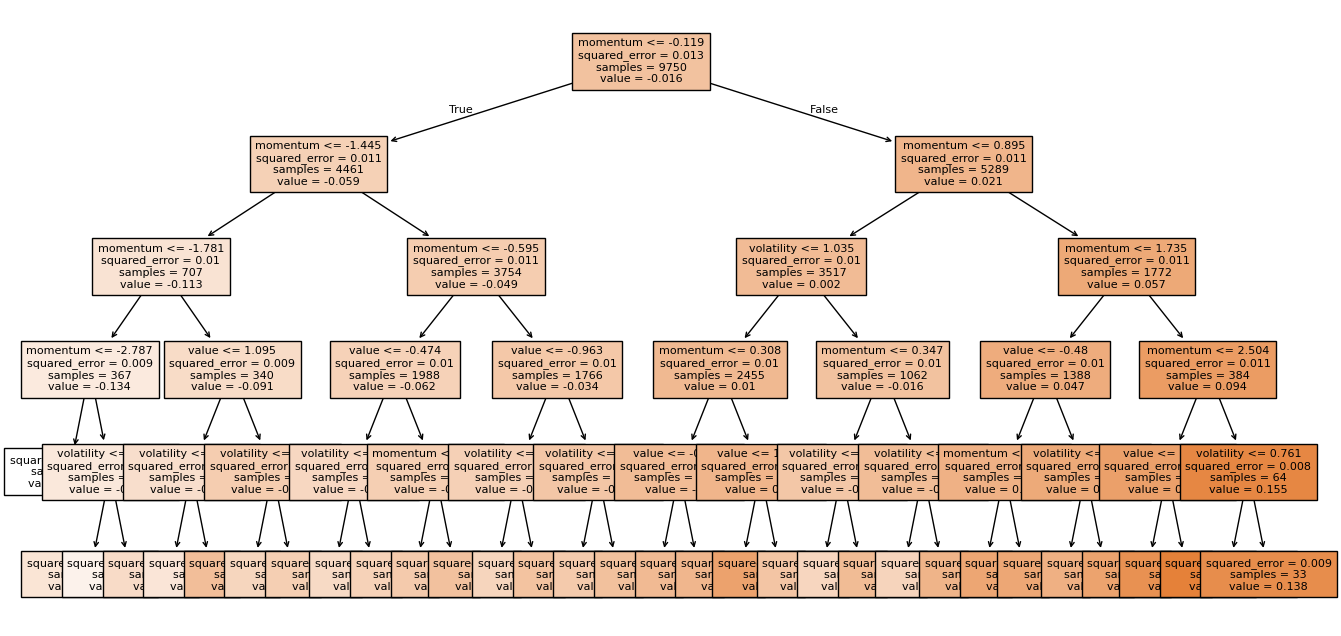

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# --- Example synthetic financial dataset ---
np.random.seed(42)
n_assets = 50
n_days = 252
dates = pd.date_range("2022-01-01", periods=n_days, freq="B")

data = pd.DataFrame({
    "date": np.tile(dates, n_assets),
    "asset": np.repeat([f"Asset_{i}" for i in range(n_assets)], n_days),
    "momentum": np.random.randn(n_assets * n_days),
    "volatility": np.abs(np.random.randn(n_assets * n_days)),
    "value": np.random.randn(n_assets * n_days),
})
data["target"] = (
    0.05 * data["momentum"]
    - 0.02 * data["volatility"]
    + 0.01 * data["value"]
    + 0.1 * np.random.randn(len(data))
)

# --- Train/Test split (time aware) ---
train = data[data["date"] < "2022-10-01"]
test = data[data["date"] >= "2022-10-01"]

X_train, y_train = train[["momentum", "volatility", "value"]], train["target"]
X_test, y_test = test[["momentum", "volatility", "value"]], test["target"]

# --- Fit Regression Tree ---
dt = DecisionTreeRegressor(max_depth=5, min_samples_leaf=20, random_state=42)
dt.fit(X_train, y_train)

# --- Predictions ---
y_pred = dt.predict(X_test)

# --- Metrics ---
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Test MSE: {mse:.6f}, R2: {r2:.4f}")

# --- Plot the tree ---
plt.figure(figsize=(16, 8))
plot_tree(dt, feature_names=X_train.columns, filled=True, fontsize=8)
plt.show()
